In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from transformers import RobertaTokenizer, RobertaModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from collections import Counter
import re


In [12]:
# === Config ===
model_type = "roberta_only"  # Options: "roberta_only", "bilstm_only", "roberta_bilstm"
epochs = 10
patience = 5
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Subjectivity Detection

In [13]:
# === Load Data ===
def load_data(file_path):
    data = pd.read_csv(file_path).dropna(subset=["review_text", "Final Sentiment"])
    data = data[["review_text", "Final Sentiment"]]
    print(f"Loaded {len(data)} rows from {file_path}")
    return data

data = load_data("annotated_microtext_lemma.csv")
data["subjectivity"] = data["Final Sentiment"].apply(
    lambda x: "Subjective" if x in ["positive", "negative"] else "Objective"
)

le = LabelEncoder()
data["encoded_subjectivity"] = le.fit_transform(data["subjectivity"])

train_texts, test_texts, train_labels, test_labels = train_test_split(
    data["review_text"].tolist(),
    data["encoded_subjectivity"].tolist(),
    test_size=0.2,
    random_state=42,
)


Loaded 1249 rows from annotated_microtext_lemma.csv


In [14]:
# === Tokenizers ===
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# For BiLSTM-only (simple tokenizer)
def simple_tokenizer(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    return tokens


In [15]:
# === Build vocabulary for BiLSTM ===
all_tokens = [token for text in train_texts for token in simple_tokenizer(text)]
vocab = {word: idx + 2 for idx, (word, _) in enumerate(Counter(all_tokens).items())}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1
vocab_size = len(vocab)

def encode_text(text, max_len=128):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids


In [16]:
# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


In [17]:
# === Dataset ===
class SubjectivityDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SubjectivityDataset(train_encodings, train_labels)
test_dataset = SubjectivityDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [18]:
# === Models ===
class RobertaOnlyModel(nn.Module):
    def __init__(self, output_dim=2):
        super(RobertaOnlyModel, self).__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.roberta.config.hidden_size, output_dim)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        return self.fc(pooled_output)

class BiLSTMOnlyModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=128, output_dim=2):
        super(BiLSTMOnlyModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        lstm_out, _ = self.lstm(x)
        pooled_output = self.dropout(lstm_out[:, -1, :])
        return self.fc(pooled_output)

class RobertaBiLSTMModel(nn.Module):
    def __init__(self, hidden_dim=128, output_dim=2):
        super(RobertaBiLSTMModel, self).__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.lstm = nn.LSTM(
            self.roberta.config.hidden_size,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        lstm_out, _ = self.lstm(outputs.last_hidden_state)
        pooled_output = self.dropout(lstm_out[:, -1, :])
        return self.fc(pooled_output)


In [19]:
# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        
        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6612, Val Loss = 0.6292
Epoch 2: Train Loss = 0.6315, Val Loss = 0.6309
Epoch 3: Train Loss = 0.6036, Val Loss = 0.5989
Epoch 4: Train Loss = 0.5202, Val Loss = 0.5987
Epoch 5: Train Loss = 0.4899, Val Loss = 0.6137
Epoch 6: Train Loss = 0.4663, Val Loss = 0.6352
Epoch 7: Train Loss = 0.4312, Val Loss = 0.6401
Epoch 8: Train Loss = 0.4323, Val Loss = 0.6499
Epoch 9: Train Loss = 0.4268, Val Loss = 0.6520
Early stopping triggered at epoch 9



Accuracy: 0.6960
Classification Report:
               precision    recall  f1-score   support

   Objective       0.52      0.40      0.45        78
  Subjective       0.75      0.83      0.79       172

    accuracy                           0.70       250
   macro avg       0.63      0.61      0.62       250
weighted avg       0.68      0.70      0.68       250



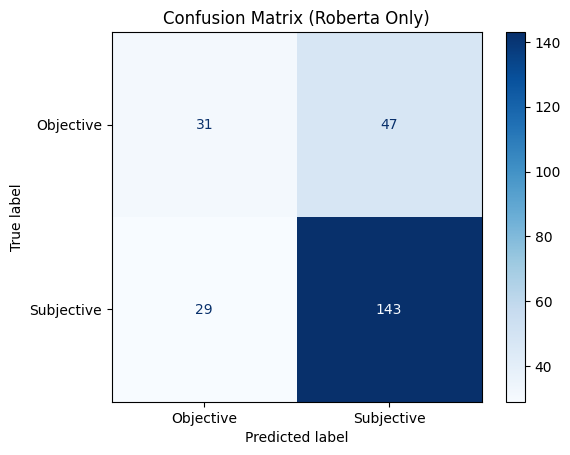

In [21]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


### bilstm

In [27]:
model_type = "bilstm_only" # Options: "roberta_only", "bilstm_only", "roberta_bilstm"

# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


train_dataset = SubjectivityDataset(train_encodings, train_labels)
test_dataset = SubjectivityDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


In [28]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        
        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6588, Val Loss = 0.6381
Epoch 2: Train Loss = 0.6550, Val Loss = 0.6365
Epoch 3: Train Loss = 0.6597, Val Loss = 0.6353
Epoch 4: Train Loss = 0.6538, Val Loss = 0.6355
Epoch 5: Train Loss = 0.6544, Val Loss = 0.6357
Epoch 6: Train Loss = 0.6524, Val Loss = 0.6357
Epoch 7: Train Loss = 0.6560, Val Loss = 0.6357
Epoch 8: Train Loss = 0.6569, Val Loss = 0.6357
Early stopping triggered at epoch 8



Accuracy: 0.6680
Classification Report:
               precision    recall  f1-score   support

   Objective       0.14      0.01      0.02        78
  Subjective       0.68      0.97      0.80       172

    accuracy                           0.67       250
   macro avg       0.41      0.49      0.41       250
weighted avg       0.51      0.67      0.56       250



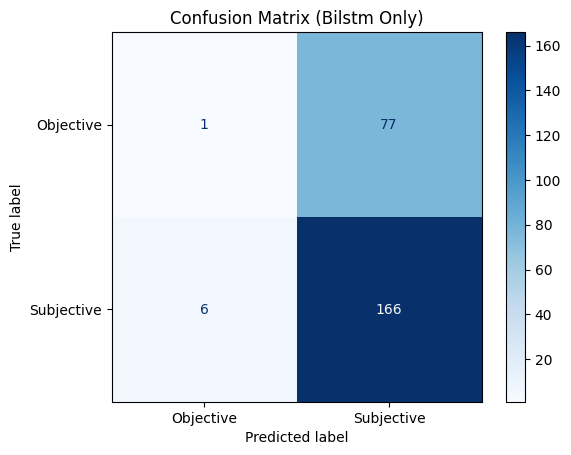

In [29]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


### roberta_bilstm

In [30]:
model_type = "roberta_bilstm" # Options: "roberta_only", "bilstm_only", "roberta_bilstm"

# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


train_dataset = SubjectivityDataset(train_encodings, train_labels)
test_dataset = SubjectivityDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        
        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6478, Val Loss = 0.6262
Epoch 2: Train Loss = 0.6198, Val Loss = 0.6001
Epoch 3: Train Loss = 0.5844, Val Loss = 0.6196
Epoch 4: Train Loss = 0.5102, Val Loss = 0.6040
Epoch 5: Train Loss = 0.4754, Val Loss = 0.6092
Epoch 6: Train Loss = 0.4489, Val Loss = 0.6235
Epoch 7: Train Loss = 0.4276, Val Loss = 0.6228
Early stopping triggered at epoch 7



Accuracy: 0.6880
Classification Report:
               precision    recall  f1-score   support

   Objective       0.50      0.42      0.46        78
  Subjective       0.76      0.81      0.78       172

    accuracy                           0.69       250
   macro avg       0.63      0.62      0.62       250
weighted avg       0.68      0.69      0.68       250



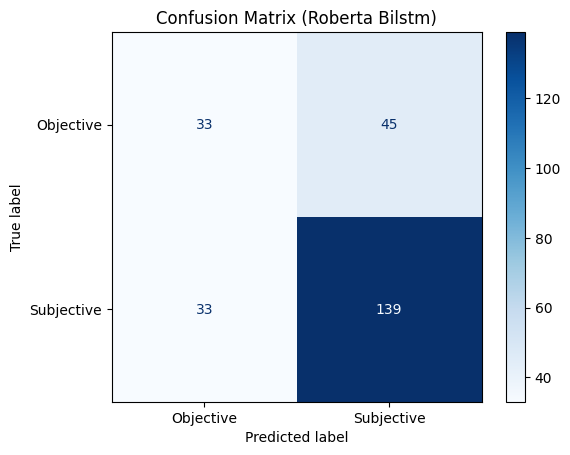

In [32]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


## Polarity Detection

In [51]:
# === Config ===
model_type = "roberta_only"  # Options: "roberta_only", "bilstm_only", "roberta_bilstm"
epochs = 10
patience = 5
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [58]:
data = load_data("annotated_microtext_lemma.csv")

# Only keep positive or negative sentiments
data = data[data["Final Sentiment"].isin(["positive", "negative"])]
data = data.dropna(subset=["Final Sentiment"])
data = data.reset_index(drop=True)
print(f"Filtered {len(data)} reviews with positive/negative sentiments.")
print(f"Final Sentiment Counts:\n{data['Final Sentiment'].value_counts()}")

le = LabelEncoder()
data['encoded_polarity'] = le.fit_transform(data['Final Sentiment'])

print(f"Polarity Detection: {data['encoded_polarity'].value_counts()}")

train_texts, test_texts, train_labels, test_labels = train_test_split(
    data["review_text"].tolist(),
    data["encoded_polarity"].tolist(),
    test_size=0.2,
    random_state=42,
)


Loaded 1249 rows from annotated_microtext_lemma.csv
Filtered 829 reviews with positive/negative sentiments.
Final Sentiment Counts:
Final Sentiment
negative    416
positive    413
Name: count, dtype: int64
Polarity Detection: encoded_polarity
0    416
1    413
Name: count, dtype: int64


In [59]:
# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


In [60]:
# Custom Dataset
class PolarityDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = PolarityDataset(train_encodings, train_labels)
test_dataset = PolarityDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)



In [61]:
# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [62]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        
        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6988, Val Loss = 0.6868
Epoch 2: Train Loss = 0.6289, Val Loss = 0.6971
Epoch 3: Train Loss = 0.4223, Val Loss = 0.5439
Epoch 4: Train Loss = 0.3100, Val Loss = 0.4912
Epoch 5: Train Loss = 0.2696, Val Loss = 0.4936
Epoch 6: Train Loss = 0.2572, Val Loss = 0.4893
Epoch 7: Train Loss = 0.2264, Val Loss = 0.4925
Epoch 8: Train Loss = 0.2165, Val Loss = 0.4943
Epoch 9: Train Loss = 0.2343, Val Loss = 0.4950
Epoch 10: Train Loss = 0.2157, Val Loss = 0.4952



Accuracy: 0.8253
Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.78      0.82        86
    positive       0.79      0.88      0.83        80

    accuracy                           0.83       166
   macro avg       0.83      0.83      0.83       166
weighted avg       0.83      0.83      0.83       166



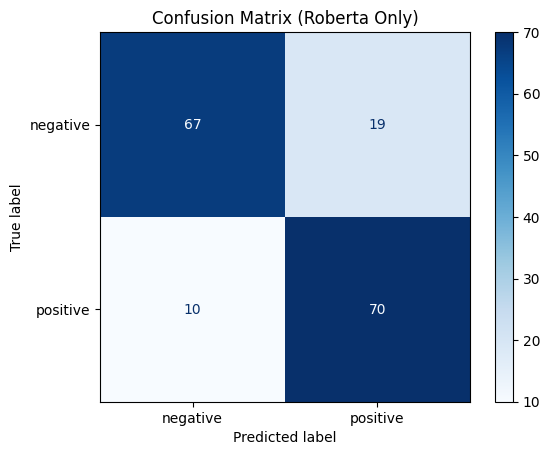

In [63]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


In [64]:
# Save the trained model's state_dict
torch.save(model.state_dict(), "roberta_polarity.pth")


## bilstm

In [65]:
model_type = "bilstm_only" # Options: "roberta_only", "bilstm_only", "roberta_bilstm"

# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


train_dataset = PolarityDataset(train_encodings, train_labels)
test_dataset = PolarityDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


In [66]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        
        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.7041, Val Loss = 0.6921
Epoch 2: Train Loss = 0.6971, Val Loss = 0.6941
Epoch 3: Train Loss = 0.6926, Val Loss = 0.6947
Epoch 4: Train Loss = 0.6898, Val Loss = 0.6947
Epoch 5: Train Loss = 0.6896, Val Loss = 0.6949
Epoch 6: Train Loss = 0.6965, Val Loss = 0.6947
Early stopping triggered at epoch 6



Accuracy: 0.4880
Classification Report:
               precision    recall  f1-score   support

    negative       0.57      0.05      0.09        86
    positive       0.48      0.96      0.64        80

    accuracy                           0.49       166
   macro avg       0.53      0.50      0.37       166
weighted avg       0.53      0.49      0.36       166



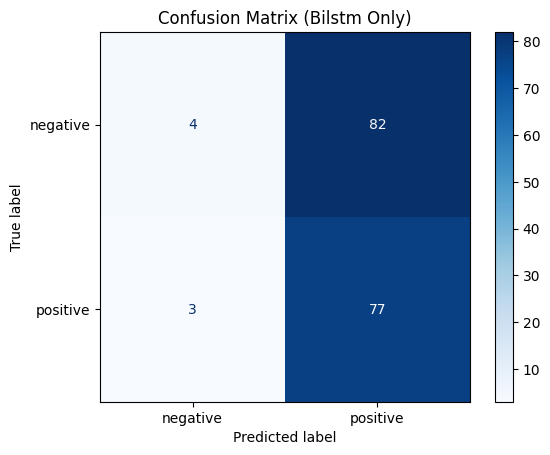

In [67]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


## roberta_bilstm

In [68]:
model_type = "roberta_bilstm" # Options: "roberta_only", "bilstm_only", "roberta_bilstm"

# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


train_dataset = PolarityDataset(train_encodings, train_labels)
test_dataset = PolarityDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [69]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        
        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6998, Val Loss = 0.6995
Epoch 2: Train Loss = 0.6833, Val Loss = 0.6549
Epoch 3: Train Loss = 0.5206, Val Loss = 0.4571
Epoch 4: Train Loss = 0.3456, Val Loss = 0.4512
Epoch 5: Train Loss = 0.3161, Val Loss = 0.4607
Epoch 6: Train Loss = 0.2986, Val Loss = 0.4640
Epoch 7: Train Loss = 0.2827, Val Loss = 0.4530
Epoch 8: Train Loss = 0.2775, Val Loss = 0.4536
Epoch 9: Train Loss = 0.2722, Val Loss = 0.4448
Epoch 10: Train Loss = 0.2704, Val Loss = 0.4453



Accuracy: 0.8554
Classification Report:
               precision    recall  f1-score   support

    negative       0.91      0.80      0.85        86
    positive       0.81      0.91      0.86        80

    accuracy                           0.86       166
   macro avg       0.86      0.86      0.86       166
weighted avg       0.86      0.86      0.86       166



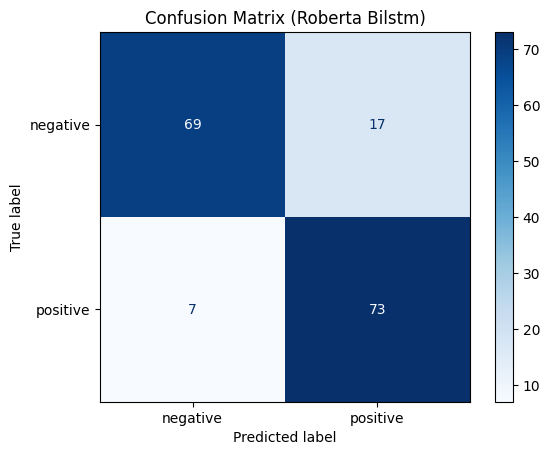

In [70]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


In [ ]:
# Save the trained model's state_dict
torch.save(model.state_dict(), "roberta_bilstm_polarity.pth")